In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Check if Apple GPU is available, otherwise use CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
def generate_dummy_data(n_samples=200, seed=42):
    np.random.seed(seed)
    
    # Simulating XGBoost output — 2 values per sample
    # [P(depressed), P(not depressed)] — must sum to 1
    xgb_prob = np.random.dirichlet(alpha=[1, 1], size=n_samples).astype(np.float32)
    
    # Simulating DistilBERT CLS embedding — 768 values per sample
    # Real embeddings are roughly normally distributed around 0
    nlp_embeddings = np.random.randn(n_samples, 768).astype(np.float32)
    
    # Binary labels — 0 = not depressed, 1 = depressed
    # Using XGBoost probability to make labels realistic
    binary_labels = (xgb_prob[:, 0] > 0.5).astype(np.float32)
    
    # Severity labels — only meaningful for depressed samples (binary = 1)
    # 0=Normal, 1=Mild, 2=Moderate, 3=Severe, 4=Extremely Severe
    severity_labels = np.random.randint(0, 5, size=n_samples).astype(np.int64)
    
    print(f"Generated {n_samples} samples")
    print(f"XGBoost output shape: {xgb_prob.shape}")
    print(f"NLP embedding shape: {nlp_embeddings.shape}")
    print(f"Depressed samples: {int(binary_labels.sum())} / {n_samples}")
    
    return xgb_prob, nlp_embeddings, binary_labels, severity_labels

xgb_prob, nlp_embeddings, binary_labels, severity_labels = generate_dummy_data(200)

Generated 200 samples
XGBoost output shape: (200, 2)
NLP embedding shape: (200, 768)
Depressed samples: 104 / 200


In [4]:
class DepressionDataset(Dataset):
    
    def __init__(self, xgb_features, nlp_embeddings, binary_labels, severity_labels):
        # Concatenate the two inputs into one vector: 2 + 768 = 770 values
        combined = np.concatenate([xgb_features, nlp_embeddings], axis=1)
        
        # Convert everything to PyTorch tensors
        self.X = torch.tensor(combined, dtype=torch.float32)
        self.y_binary = torch.tensor(binary_labels, dtype=torch.float32)
        self.y_severity = torch.tensor(severity_labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y_binary[idx], self.y_severity[idx]


# Split into train (80%), validation (10%), test (10%)
# stratify= makes sure each split has a balanced mix of depressed/not depressed
X_xgb_temp, X_xgb_test, X_nlp_temp, X_nlp_test, y_bin_temp, y_bin_test, y_sev_temp, y_sev_test = train_test_split(
    xgb_prob, nlp_embeddings, binary_labels, severity_labels,
    test_size=0.1, random_state=42, stratify=binary_labels
)

X_xgb_train, X_xgb_val, X_nlp_train, X_nlp_val, y_bin_train, y_bin_val, y_sev_train, y_sev_val = train_test_split(
    X_xgb_temp, X_nlp_temp, y_bin_temp, y_sev_temp,
    test_size=0.111, random_state=42, stratify=y_bin_temp
)

# Wrap in Dataset objects
train_dataset = DepressionDataset(X_xgb_train, X_nlp_train, y_bin_train, y_sev_train)
val_dataset   = DepressionDataset(X_xgb_val,   X_nlp_val,   y_bin_val,   y_sev_val)
test_dataset  = DepressionDataset(X_xgb_test,  X_nlp_test,  y_bin_test,  y_sev_test)

# DataLoader batches the data and shuffles it during training
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 160 | Val: 20 | Test: 20


In [5]:
class FusionNetwork(nn.Module):
    
    def __init__(self, input_size=770, dropout_rate=0.3):
        super(FusionNetwork, self).__init__()
        
        # Shared trunk — processes the combined input
        # Both heads learn from this shared representation
        self.shared = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        
        # Stage 1 — binary head: depressed or not?
        self.binary_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        # Stage 2 — severity head: how severe?
        self.severity_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5)
        )
    
    def forward(self, x):
        shared_out = self.shared(x)
        binary_logit   = self.binary_head(shared_out)
        severity_logit = self.severity_head(shared_out)
        return binary_logit, severity_logit


# Initialise the model and move it to your device (GPU or CPU)
model = FusionNetwork(input_size=770, dropout_rate=0.3).to(device)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

FusionNetwork(
  (shared): Sequential(
    (0): Linear(in_features=770, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (binary_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (severity_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)

Total trainable parameters: 247,174


In [6]:
def train_model(model, train_loader, val_loader, epochs=30):
    
    binary_loss_fn   = nn.BCEWithLogitsLoss()
    severity_loss_fn = nn.CrossEntropyLoss()
    optimizer        = optim.Adam(model.parameters(), lr=1e-3)
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        
        # --- Training ---
        model.train()
        total_train_loss = 0
        
        for X_batch, y_bin_batch, y_sev_batch in train_loader:
            # Move data to same device as model
            X_batch     = X_batch.to(device)
            y_bin_batch = y_bin_batch.to(device)
            y_sev_batch = y_sev_batch.to(device)
            
            optimizer.zero_grad()
            binary_logit, severity_logit = model(X_batch)
            
            # Binary loss on all samples
            loss_binary = binary_loss_fn(binary_logit.squeeze(), y_bin_batch)
            
            # Severity loss only on depressed samples
            depressed_mask = y_bin_batch == 1
            if depressed_mask.sum() > 0:
                loss_severity = severity_loss_fn(
                    severity_logit[depressed_mask],
                    y_sev_batch[depressed_mask]
                )
                total_loss = 0.5 * loss_binary + 0.5 * loss_severity
            else:
                total_loss = loss_binary
            
            total_loss.backward()
            optimizer.step()
            total_train_loss += total_loss.item()
        
        # --- Validation ---
        model.eval()
        total_val_loss = 0
        
        with torch.no_grad():
            for X_batch, y_bin_batch, y_sev_batch in val_loader:
                X_batch     = X_batch.to(device)
                y_bin_batch = y_bin_batch.to(device)
                y_sev_batch = y_sev_batch.to(device)
                
                binary_logit, severity_logit = model(X_batch)
                loss_binary = binary_loss_fn(binary_logit.squeeze(), y_bin_batch)
                
                depressed_mask = y_bin_batch == 1
                if depressed_mask.sum() > 0:
                    loss_severity = severity_loss_fn(
                        severity_logit[depressed_mask],
                        y_sev_batch[depressed_mask]
                    )
                    val_loss = 0.5 * loss_binary + 0.5 * loss_severity
                else:
                    val_loss = loss_binary
                
                total_val_loss += val_loss.item()
        
        avg_train = total_train_loss / len(train_loader)
        avg_val   = total_val_loss   / len(val_loader)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        
        # Save best model
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), 'best_fusion_model.pt')
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:>3}/{epochs} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")
    
    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=30)

Epoch   5/30 | Train Loss: 0.3883 | Val Loss: 1.1638
Epoch  10/30 | Train Loss: 0.0059 | Val Loss: 1.4487
Epoch  15/30 | Train Loss: 0.0027 | Val Loss: 1.6552
Epoch  20/30 | Train Loss: 0.0013 | Val Loss: 1.6859
Epoch  25/30 | Train Loss: 0.0006 | Val Loss: 1.7068
Epoch  30/30 | Train Loss: 0.0006 | Val Loss: 1.7269

Training complete. Best val loss: 1.0969


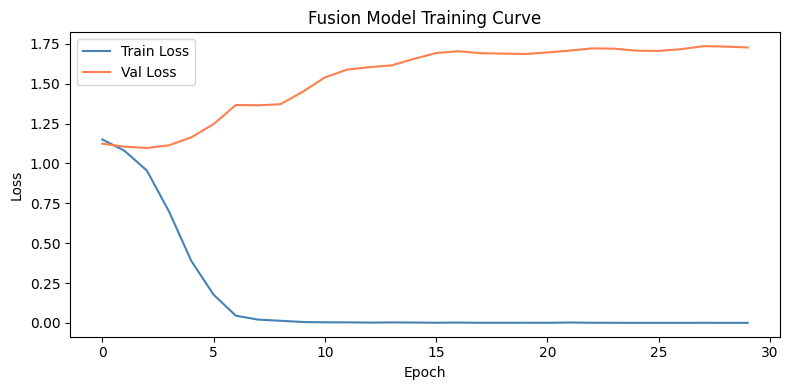

Plot saved as training_curve.png


In [7]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='coral')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fusion Model Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()
print("Plot saved as training_curve.png")

In [8]:
def evaluate(model, test_loader):
    model.eval()
    
    all_bin_preds, all_bin_labels = [], []
    all_sev_preds, all_sev_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_bin_batch, y_sev_batch in test_loader:
            X_batch = X_batch.to(device)
            
            binary_logit, severity_logit = model(X_batch)
            
            # Convert logits to predictions
            bin_probs = torch.sigmoid(binary_logit).squeeze().cpu().numpy()
            bin_preds = (bin_probs > 0.5).astype(int)
            
            sev_preds = torch.argmax(severity_logit, dim=1).cpu().numpy()
            
            all_bin_preds.extend(bin_preds)
            all_bin_labels.extend(y_bin_batch.numpy())
            all_sev_preds.extend(sev_preds)
            all_sev_labels.extend(y_sev_batch.numpy())
    
    all_bin_preds  = np.array(all_bin_preds)
    all_bin_labels = np.array(all_bin_labels)
    all_sev_preds  = np.array(all_sev_preds)
    all_sev_labels = np.array(all_sev_labels)
    
    print("=" * 50)
    print("STAGE 2 — Severity Classification (depressed samples only)")
    print("=" * 50)
    depressed_mask = all_bin_labels == 1
    severity_names = ["Normal", "Mild", "Moderate", "Severe", "Extremely Severe"]
    
    sev_true = all_sev_labels[depressed_mask]
    sev_pred = all_sev_preds[depressed_mask]
    
    # Get only the classes that actually appear in this split
    present_classes = sorted(np.unique(np.concatenate([sev_true, sev_pred])))
    present_names   = [severity_names[i] for i in present_classes]
    
    print(classification_report(
        sev_true, sev_pred,
        labels=present_classes,
        target_names=present_names
    ))

# Load the best saved model before evaluating
model.load_state_dict(torch.load('best_fusion_model.pt', map_location=device))
evaluate(model, test_loader)

STAGE 2 — Severity Classification (depressed samples only)
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         5
        Mild       0.00      0.00      0.00         3
      Severe       0.20      1.00      0.33         2

    accuracy                           0.20        10
   macro avg       0.07      0.33      0.11        10
weighted avg       0.04      0.20      0.07        10



/Users/siddharthanand21/mindscope_fusion/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/siddharthanand21/mindscope_fusion/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/siddharthanand21/mindscope_fusion/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [9]:
def predict(model, xgb_prob_vector, nlp_embedding, threshold=0.60):
    model.eval()
    
    combined = np.concatenate([xgb_prob_vector, nlp_embedding])
    x = torch.tensor(combined, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        binary_logit, severity_logit = model(x)
    
    depression_prob = torch.sigmoid(binary_logit).item()
    
    # Confidence gate
    if 0.5 - threshold/2 < depression_prob < 0.5 + threshold/2:
        return {
            "result": "uncertain",
            "message": "Not confident enough to assess. Please speak with a counsellor."
        }
    
    if depression_prob < 0.5:
        return {
            "result": "not_depressed",
            "depression_probability": round(depression_prob, 3),
            "message": "No significant indicators of depression detected."
        }
    
    severity_probs = torch.softmax(severity_logit, dim=1).squeeze()
    severity_idx   = torch.argmax(severity_probs).item()
    severity_map   = {0: "Normal", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Extremely Severe"}
    
    return {
        "result": "depressed",
        "depression_probability": round(depression_prob, 3),
        "severity": severity_map[severity_idx],
        "severity_confidence": round(severity_probs[severity_idx].item(), 3),
        "message": f"Depression indicators detected. Severity: {severity_map[severity_idx]}"
    }


# Test it with one fake sample
fake_xgb   = np.array([0.82, 0.18], dtype=np.float32)
fake_embed = np.random.randn(768).astype(np.float32)

result = predict(model, fake_xgb, fake_embed)
print(result)

{'result': 'uncertain', 'message': 'Not confident enough to assess. Please speak with a counsellor.'}
